In [1]:
# Training name
training_name = 'Transformer120e_2bit'

# Gaussian noise parameters
NOISE_MU = 0.0
NOISE_SIGMA = 120.0 # e-

# Precision of input data
N_BITS = 2

In [2]:
# IMPORTS ---------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import os, subprocess
from pathlib import Path
import random

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

from models import *
from plotting import *

2026-07-08 00:43:05.174652: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# DATA ---------------------------------------------------------------------

dataset_base_dir = "/uscms/home/bweiss/nobackup/smart-pixels/"
tfrecords_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/tfrecords"

dataset_dir_val = os.path.join(dataset_base_dir, "dataset_3sr_16x16_50x12P5_centeredIncidence_parquets", 'test_contained/')
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val",'3sr_16x16_'+str(int(NOISE_SIGMA))+'eNoise_test')

In [4]:
seeds = grep('Seed','log_'+training_name+'.txt')
print("Seeds = ", seeds)

fingerprints = grep('Fingerprint','log_'+training_name+'.txt')
print("Fingerprints = ", fingerprints)
    
residuals = {}
thresholds = {}
best_epoch = {}

# BEGIN LOOP ---------------------------------------------------------------------
for i in range(len(fingerprints)):

    base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
    if not os.path.exists(base_dir):
        print("Fingerprint " + fingerprints[i] + " not found")
        continue
        
    checkpoint_dir = base_dir + 'checkpoints/'
    checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
    #latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    
    checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
    best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]
    os.system('cp '+best_checkpoint+' ' +base_dir)

    best_epoch[i] = int(best_checkpoint.split('weights.')[1].split('-t')[0])

    model = create_vit_model(input_shape=(16,16,2),   
                             patch_size=(3,4),        
                             embed_dim=64,           
                             num_heads=4,            
                             ff_dim=128,              
                             num_layers=4,            
                             dropout=0.1,        
                             n_bits=N_BITS,
                             final_outputs=14         
                            )

    print(f"Loading model from {best_checkpoint}")
    model.load_weights(best_checkpoint)

    test_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_val,
        shuffle=True,
        seed=int(seeds[i]),
        quantize=False,
    )

    sf = test_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotA'] = sf[2]
    scale_factor['cotB'] = sf[3]

    df = construct_df(model, test_generator, scale_factor)
    df.to_parquet(base_dir+"residuals.parquet")
    residuals[i] = df

    thr = pd.read_csv(base_dir+'soft_quantizer_state_log.csv',header=0,index_col=0,usecols=['epoch'] + ['threshold_'+str(i) for i in range(0,3)])
    thresholds[i] = thr


Seeds =  ['550', '104', '721', '722', '706']
Fingerprints =  ['923bc2f5', '4794f4fb', 'f4865d7a', '08541804', '9f083410']
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-923bc2f5-Transformer120e_2bit-checkpoints/checkpoints/weights.2305-t-44562.82-v-45915.14.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_120eNoise_test/metadata.json


21/21 [==============================] - 4s 151ms/step


100%|██████████| 21/21 [00:01<00:00, 16.57it/s]


0.20174779 -0.60974187 1.0162302
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-4794f4fb-Transformer120e_2bit-checkpoints/checkpoints/weights.3448-t-44748.58-v-46105.92.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_120eNoise_test/metadata.json


21/21 [==============================] - 3s 140ms/step


...

100%|██████████| 21/21 [00:01<00:00, 17.86it/s]


0.20174779 -0.60974187 1.0162302
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-9f083410-Transformer120e_2bit-checkpoints/checkpoints/weights.4943-t-45146.41-v-46398.61.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_120eNoise_test/metadata.json


21/21 [==============================] - 3s 138ms/step


100%|██████████| 21/21 [00:01<00:00, 17.66it/s]


0.20174779 -0.60974187 1.0162302


923bc2f5 2305
4794f4fb 3448
f4865d7a 3787
08541804 4886
9f083410 4943


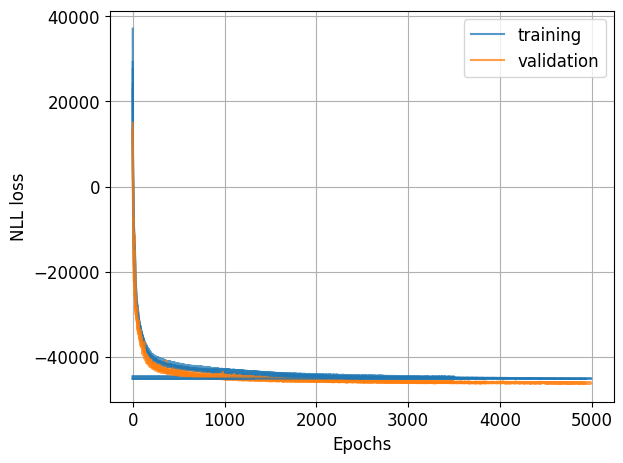

In [5]:
for i in range(len(fingerprints)):

    try:
    
        base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
        if not os.path.exists(base_dir):
            print("Fingerprint " + fingerprints[i] + " not found")
            continue

        training_cp_path = os.path.join(base_dir, 'training_log.csv')
        training_history = pd.read_csv(training_cp_path)

        print(fingerprints[i], best_epoch[i])

        plt.plot(training_history['epoch'][:best_epoch[i]+50], training_history['loss'][:best_epoch[i]+50], linestyle='-', color=colors[0], alpha=0.75)
        plt.plot(training_history['epoch'][:best_epoch[i]+50], training_history['val_loss'][:best_epoch[i]+50], linestyle='-', color=colors[1], alpha=0.75)
        plt.plot(training_history['epoch'][:best_epoch[i]+50], (best_epoch[i]+50)*[training_history['loss'][best_epoch[i]]], linestyle='-', color=colors[0], alpha=0.75)


    except ValueError:
        print("History not available for model " + fingerprints[i] + " at epoch " + str(best_epoch[i]))
        
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

0
1
2
3
4


(0.5, 100000)

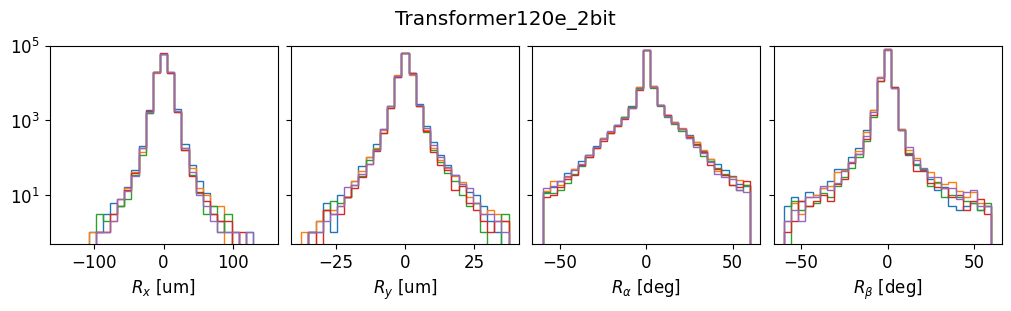

In [6]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

cols = []
for v in ['x','y','A','B','cotA','cotB']:
    cols = cols + ['mean_'+v, 'std_'+v, 'up68_'+v, 'down68_'+v]
avg_residuals = pd.DataFrame(None, index=np.arange(len(fingerprints)),columns=cols)

fig, ax = plt.subplots(1,4,figsize=(10,3),sharey='row', constrained_layout=True)

for i,df in residuals.items():

    print(i)

    # x
    ax[0].set_xlabel(r'$R_x$ [um]')
    ax[0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
    ax[0].set_yscale('log')

    # y
    ax[1].set_xlabel(r'$R_y$ [um]')
    ax[1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

    # alpha
    ax[2].set_xlabel(r'$R_\alpha$ [deg]')
    ax[2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
    
    # beta
    ax[3].set_xlabel(r'$R_\beta$ [deg]')
    ax[3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
      
    # Residuals for x and y (microns)
    for v in ['x','y','A','cotA','B','cotB']:
        # Mean
        avg_residuals['mean_'+v].iloc[i] = float(np.mean(df['residual'+v]))
        # Std -- replace with smallest window containing 68%
        avg_residuals['std_'+v].iloc[i] = float(np.std(df['residual'+v]))

        interval68 = shortest_interval_68(df['residual'+v], center_type='mean')
        avg_residuals['up68_'+v].iloc[i] = interval68['error_high']
        avg_residuals['down68_'+v].iloc[i] = interval68['error_low']

avg_residuals.to_parquet("avg_res_"+training_name+".parquet")

plt.suptitle(training_name);
ax[0].set_ylim(0.5,100000)
    
#plt.tight_layout()
#plt.savefig('plots/'+training_name+'_residuals.png')

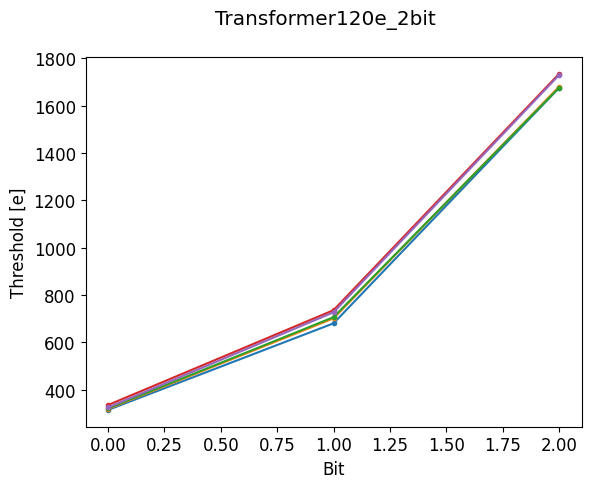

In [7]:
# OVERLAY THRESHOLDS OF ALL TRAININGS --------------------------------------

for i,df in thresholds.items():

    thr = np.array(df.iloc[best_epoch[i]].values)
    plt.plot(np.array(range(np.power(2,N_BITS)-1)), thr, linestyle='-',marker='.',label=str(i))
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

plt.suptitle(training_name);

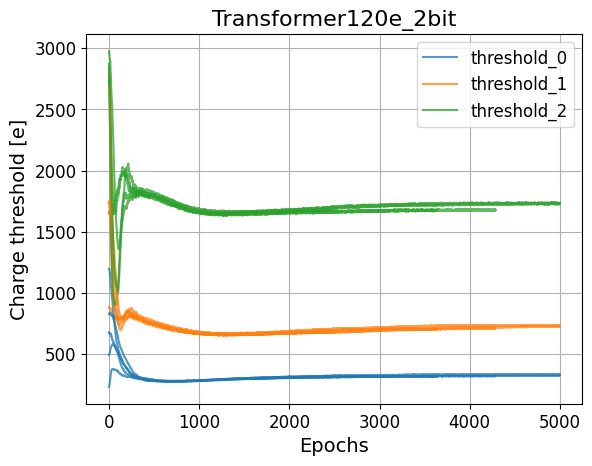

In [8]:
# THRESHOLD EVOLUTION --------------------------------------

plt.grid()


for i,df in thresholds.items():

    for i,c in enumerate(df.columns):
        epochs = df.index
        th_charge = df['threshold_'+str(i)]
        plt.plot(epochs, th_charge, linestyle='-', color=colors[i], alpha=0.75)


plt.legend([f'threshold_{i}' for i in range(3)],bbox_to_anchor=[1,1])
plt.xlabel('Epochs', fontsize =14)
plt.ylabel('Charge threshold [e]', fontsize = 14)
plt.title(training_name, fontsize = 16);


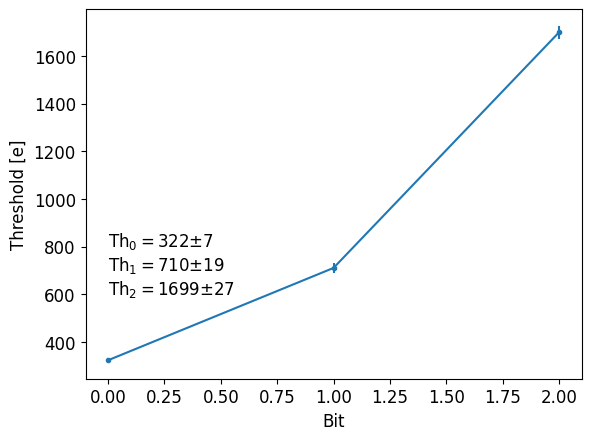

In [9]:
# AVERAGE THRESHOLDS --------------------------------------

th0 = [thresholds[i].iloc[best_epoch[i]][0] for i in range(len(best_epoch))]
th1 = [thresholds[i].iloc[best_epoch[i]][1] for i in range(len(best_epoch))]
th2 = [thresholds[i].iloc[best_epoch[i]][2] for i in range(len(best_epoch))]

th0_mean = np.mean(th0)
th0_sigma = np.std(th0)

th1_mean = np.mean(th1)
th1_sigma = np.std(th1)

th2_mean = np.mean(th2)
th2_sigma = np.std(th2)

plt.errorbar(x=np.array(range(np.power(2,N_BITS)-1)), y=[th0_mean,th1_mean,th2_mean], yerr=[th0_sigma,th1_sigma,th2_sigma], 
             linestyle='-',marker='.',label=training_name)
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

plt.text(0,800,r"Th$_0=$"+str(int(th0_mean))+"$\pm$"+str(int(th0_sigma)))
plt.text(0,700,r"Th$_1=$"+str(int(th1_mean))+"$\pm$"+str(int(th1_sigma)))
plt.text(0,600,r"Th$_2=$"+str(int(th2_mean))+"$\pm$"+str(int(th2_sigma)))

data = np.array([[th0_mean,th0_sigma],[th1_mean,th1_sigma],[th2_mean,th2_sigma]])
df = pd.DataFrame(data,columns=['mean','sigma'])

df.to_parquet("avg_thr_"+training_name+".parquet")

In [10]:
# EVALUATE ON DATASET 2S

In [11]:
# DATA ---------------------------------------------------------------------

dataset_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/"
tfrecords_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/tfrecords/"

dataset_dir_test = os.path.join(dataset_base_dir, "dataset_2s_16x16_50x12P5_centeredIncidence_parquets", 'test_contained/')
tfrecords_dir_test   = os.path.join(tfrecords_base_dir, "TFR_test",'2s_16x16_'+str(int(NOISE_SIGMA))+'eNoise_test')

In [12]:
seeds = grep('Seed','log_'+training_name+'.txt')
print("Seeds = ", seeds)

fingerprints = grep('Fingerprint','log_'+training_name+'.txt')
print("Fingerprints = ", fingerprints)
    
residuals = {}
thresholds = {}
best_epoch = {}

# BEGIN LOOP ---------------------------------------------------------------------
for i in range(len(fingerprints)):

    base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
    if not os.path.exists(base_dir):
        print("Fingerprint " + fingerprints[i] + " not found")
        continue
        
    checkpoint_dir = base_dir + 'checkpoints/'
    checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
    #latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    
    checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
    best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]
    os.system('cp '+best_checkpoint+' ' +base_dir)

    best_epoch[i] = int(best_checkpoint.split('weights.')[1].split('-t')[0])

    model = create_vit_model(input_shape=(16,16,2),   
                             patch_size=(3,4),        
                             embed_dim=64,           
                             num_heads=4,            
                             ff_dim=128,              
                             num_layers=4,            
                             dropout=0.1,        
                             n_bits=N_BITS,
                             final_outputs=14         
                            )

    print(f"Loading model from {best_checkpoint}")
    model.load_weights(best_checkpoint)

    test_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_test,
        shuffle=True,
        seed=int(seeds[i]),
        quantize=False,
    )

    sf = test_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotA'] = sf[2]
    scale_factor['cotB'] = sf[3]

    df = construct_df(model, test_generator, scale_factor, is2s = True)
    df.to_parquet(base_dir+"residuals_2s.parquet")
    residuals[i] = df


Seeds =  ['550', '104', '721', '722', '706']
Fingerprints =  ['923bc2f5', '4794f4fb', 'f4865d7a', '08541804', '9f083410']
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-923bc2f5-Transformer120e_2bit-checkpoints/checkpoints/weights.2305-t-44562.82-v-45915.14.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_test/2s_16x16_120eNoise_test/metadata.json


278/278 [==============================] - 48s 171ms/step


100%|██████████| 278/278 [00:17<00:00, 15.95it/s]


0.203404 -0.6087434 1.0145767
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-4794f4fb-Transformer120e_2bit-checkpoints/checkpoints/weights.3448-t-44748.58-v-46105.92.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_test/2s_16x16_120eNoise_test/metadata.json


278/278 [==============================] - 37s 130ms/step


...

100%|██████████| 278/278 [00:14<00:00, 18.61it/s]


0.203404 -0.6087434 1.0145767
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-9f083410-Transformer120e_2bit-checkpoints/checkpoints/weights.4943-t-45146.41-v-46398.61.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_test/2s_16x16_120eNoise_test/metadata.json


278/278 [==============================] - 36s 129ms/step


100%|██████████| 278/278 [00:14<00:00, 18.60it/s]


0.203404 -0.6087434 1.0145767


0
1
2
3
4


(0.5, 10000000)

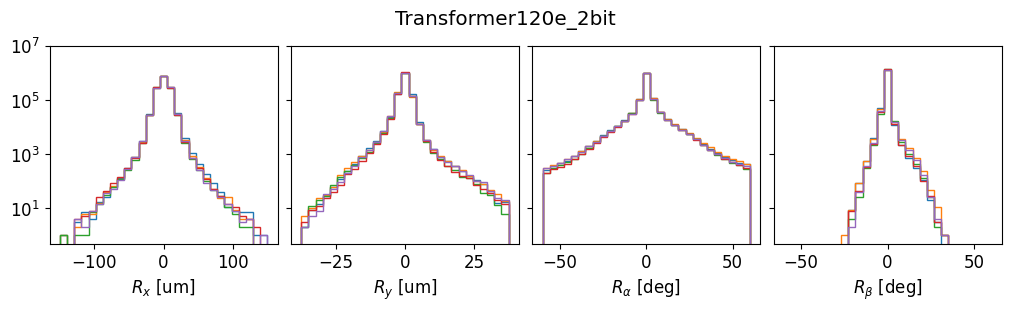

In [13]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

cols = []
for v in ['x','y','A','B','cotA','cotB']:
    cols = cols + ['mean_'+v, 'std_'+v, 'up68_'+v, 'down68_'+v]
avg_residuals = pd.DataFrame(None, index=np.arange(len(fingerprints)),columns=cols)

fig, ax = plt.subplots(1,4,figsize=(10,3),sharey='row', constrained_layout=True)

for i,df in residuals.items():

    print(i)

    # x
    ax[0].set_xlabel(r'$R_x$ [um]')
    ax[0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
    ax[0].set_yscale('log')

    # y
    ax[1].set_xlabel(r'$R_y$ [um]')
    ax[1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

    # alpha
    ax[2].set_xlabel(r'$R_\alpha$ [deg]')
    ax[2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
    
    # beta
    ax[3].set_xlabel(r'$R_\beta$ [deg]')
    ax[3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
      
    # Residuals for x and y (microns)
    for v in ['x','y','A','cotA','B','cotB']:
        # Mean
        avg_residuals['mean_'+v].iloc[i] = float(np.mean(df['residual'+v]))
        # Std -- replace with smallest window containing 68%
        avg_residuals['std_'+v].iloc[i] = float(np.std(df['residual'+v]))

        interval68 = shortest_interval_68(df['residual'+v], center_type='mean')
        avg_residuals['up68_'+v].iloc[i] = interval68['error_high']
        avg_residuals['down68_'+v].iloc[i] = interval68['error_low']

avg_residuals.to_parquet("avg_res_2s_"+training_name+".parquet")

plt.suptitle(training_name);
ax[0].set_ylim(0.5,10000000)
    
#plt.tight_layout()
#plt.savefig('plots/'+training_name+'_residuals.png')